### How to use conditional edges :
* Implement conditional logic to route the flow of data to diff nodes
* Design multiple nodes to perform diff operations
* Create a router node to handle decision making and control grant flow 
* MAIN GOAL : Understand how to use add_conditional_edge()

In [1]:
from typing import TypedDict, List 
from langgraph.graph import StateGraph, START, END 

In [2]:
class AgentState(TypedDict):
    num1 : int
    num2 : int
    operator : str 
    result : int 

In [3]:
# Addition node
def adder(state: AgentState) -> AgentState:
    """Adds the two numbers"""
    state['result'] = state['num1'] + state['num2']
    return state

# Subtraction node
def subtractor(state: AgentState) -> AgentState:
    """Subtracts the two numbers"""
    state['result'] = state['num1'] - state['num2']
    return state

# Decision function
def router_fn(state: AgentState) -> str:
    """Simple function(not a node) that decides which edge to pick next"""
    if state['operator'] == "+":
        return "addition_edge"
    elif state['operator'] == "-":
        return "subtraction_edge"

### Conditional edge logic
* So basically you need a decision/router function that reads the state, does some logic and returns which edge to take
* Each edge takes you to some specific downstream node
* You need a path_map that maps each edge to the downstream node it connects to
* LEN(PATH_MAP) = # of unique edge names returned by router_fn

#### Syntax of add_conditional_edges :
* Takes 3 arguments only
* Source node which just got executed
* Router fn that returns which edge to go THROUGH next based on some logic
* PATH_MAP that maps the edge you came through to the next node you need to go to

In [4]:
graph = StateGraph(AgentState)

graph.add_node("addition node", adder)
graph.add_node("subtraction node", subtractor)

graph.add_conditional_edges(
    START, 
    router_fn,
    path_map={
        "addition_edge" : "addition node",
        "subtraction_edge" : "subtraction node"
    }
)

graph.add_edge("addition node", END)
graph.add_edge("subtraction node", END)

app = graph.compile()

In [5]:
result = app.invoke({'num1':10, 'num2': 5, 'operator' : "+"})
result['result']

15

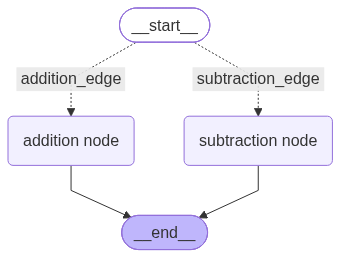

In [ ]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))